# Subjective analysis of the questionnaire

Produces only the numbers and plots that are referenced in the thesis (§4.4.1 sample, §4.4.2 subjective measures, §4.4.4 qualitative observations). Latency and other objective metrics live in `objective_analysis_2.ipynb`.

Each subjective plot groups respondents by the **condition they experienced** in the experiment:

- **A** (blue) — visitors whose session was Condition A (local cascade)
- **B** (orange) — visitors whose session was Condition B (cloud cascade)
- **unknown** (grey) — visitors whose session could not be matched to a log (see `matching.ipynb`)

The condition assignment comes from `matched_sessions.csv`. The split is for visualisation only — at n=11 A / 9 B / 6 unknown the comparison is descriptive, not inferential.

## Section 0 — Setup

In [43]:
import csv
import re
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = pathlib.Path.cwd()
while not (PROJECT_ROOT / "docker").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

CSV_PATH     = PROJECT_ROOT / "docs/thesis/experiment/results/results.csv"
MATCHES_PATH = PROJECT_ROOT / "docs/thesis/experiment/results/matched_sessions.csv"

COLORS     = {"A": "#3b6db7", "B": "#d8702a", "unknown": "#9e9e9e"}
COND_ORDER = ["A", "B", "unknown"]

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print(f"CSV     : {CSV_PATH}      (exists={CSV_PATH.exists()})")
print(f"MATCHES : {MATCHES_PATH}  (exists={MATCHES_PATH.exists()})")

CSV     : /home/lucas/Projects/FEL/Pepper/docs/thesis/experiment/results/results.csv      (exists=True)
MATCHES : /home/lucas/Projects/FEL/Pepper/docs/thesis/experiment/results/matched_sessions.csv  (exists=True)


## Section 1 — Load questionnaire and merge condition

Read `results.csv`, rename columns to clean snake_case, cast numeric columns, and bring in `matched_variant` from `matched_sessions.csv`. Respondents whose row could not be matched to a session log get `condition = "unknown"`.

In [44]:
raw = pd.read_csv(CSV_PATH)

CLEAN_COLS = [
    "timestamp", "conv_id", "gender", "age", "robot_familiarity",
    "task_success", "response_speed", "gesture_naturalness",
    "topic", "problem", "help_wishes", "prefer",
    # Godspeed items — keep numeric names so the order is preserved
    "anthro_1", "anthro_2", "anthro_3", "anthro_4", "anthro_5",
    "animacy_1", "animacy_2", "animacy_3", "animacy_4", "animacy_5", "animacy_6",
    "like_1", "like_2", "like_3", "like_4", "like_5",
    "intel_1", "intel_2", "intel_3", "intel_4", "intel_5",
    "comments",
]
assert raw.shape[1] == len(CLEAN_COLS), f"col count mismatch: {raw.shape[1]} vs {len(CLEAN_COLS)}"
df = raw.copy()
df.columns = CLEAN_COLS

LIKERT      = ["task_success", "response_speed", "gesture_naturalness"]
GODSPEED    = [c for c in df.columns if c.startswith(("anthro_", "animacy_", "like_", "intel_"))]
NUMERIC     = ["age", "robot_familiarity"] + LIKERT + GODSPEED
TEXT_COLS   = ["conv_id", "gender", "topic", "problem", "help_wishes", "prefer", "comments"]

for c in NUMERIC:
    df[c] = pd.to_numeric(df[c], errors="coerce")
for c in TEXT_COLS:
    df[c] = df[c].astype("string").str.strip()
df["csv_row"] = df.index

# Merge condition from matched_sessions.csv
m = pd.read_csv(MATCHES_PATH)[["csv_row", "matched_variant", "match_status"]]
df = df.merge(m, on="csv_row", how="left")
df["condition"] = df["matched_variant"].where(df["match_status"] == "matched", other="unknown").fillna("unknown")

n_per_cond = df["condition"].value_counts().reindex(COND_ORDER).fillna(0).astype(int)
print(f"Total respondents: {len(df)}")
print(f"Per condition: {dict(n_per_cond)}")
df.head()

Total respondents: 26
Per condition: {'A': np.int64(10), 'B': np.int64(10), 'unknown': np.int64(6)}


,timestamp,conv_id,gender,age,robot_familiarity,task_success,response_speed,gesture_naturalness,topic,problem,help_wishes,prefer,anthro_1,anthro_2,anthro_3,anthro_4,anthro_5,animacy_1,animacy_2,animacy_3,animacy_4,animacy_5,animacy_6,like_1,like_2,like_3,like_4,like_5,intel_1,intel_2,intel_3,intel_4,intel_5,comments,csv_row,matched_variant,match_status,condition
0,15.5.2026 15:43:01,T30,Female,49,1,5,5,5,Navigate to some room,No problem,Navigovat,Human,4,3,3,3,4,4,4,3,3,3,5,5,5,5,5,5,4,5,4,4,3,My technical skills are not strong.I am not ab...,0,B,matched,B
1,18.5.2026 9:09:55,T01,Male,28,3,2,2,3,Navigate to some room,No problem,<NA>,Pepper,2,2,1,1,2,3,2,2,2,2,4,4,4,4,4,4,2,3,3,2,4,<NA>,1,A,matched,A
2,18.5.2026 9:27:21,T08,Male,19,4,4,5,5,Navigate to some room,No problem,<NA>,Pepper,5,2,2,2,3,4,5,1,2,3,3,3,5,5,5,5,4,5,5,4,3,<NA>,2,B,matched,B
3,18.5.2026 9:31:45,T07,Male,21,5,2,4,4,"Subject schedule, Navigate to some room",The transcription of what I said was incorrect...,<NA>,Pepper,4,2,3,2,4,3,4,4,3,4,4,4,5,5,5,5,3,3,3,4,4,"It's really nice, keep developing it",3,A,matched,A
4,18.5.2026 10:16:30,T14,Male,46,3,1,4,3,Navigate to some room,"The provided information was false, The transc...",<NA>,Dotyková obrazkovka s plány pater a seznamem o...,3,1,2,2,3,3,3,3,3,3,3,2,4,4,4,4,2,3,2,2,3,<NA>,4,B,matched,B


## Section 2 — Sample composition

Basic demographics overall and per condition. Use this for §4.4.1 of the thesis.

In [45]:
print(f"=== Sample summary (n={len(df)}) ===\n")
print(df["gender"].value_counts(dropna=False).to_string())
print()
print(f"Age: median = {df['age'].median()}  (min = {df['age'].min()}, max = {df['age'].max()})")
print(f"Robot familiarity (1-5): mean = {df['robot_familiarity'].mean():.2f}, median = {df['robot_familiarity'].median()}")
print()
print("Per condition:")
display(df.groupby("condition").agg(
    n=("conv_id", "count"),
    pct_female=("gender", lambda s: 100 * (s == "Female").sum() / len(s)),
    age_median=("age", "median"),
    robot_familiarity_mean=("robot_familiarity", "mean"),
).round(2).reindex(COND_ORDER))

=== Sample summary (n=26) ===

gender
Male      22
Female     4

Age: median = 25.5  (min = 19, max = 49)
Robot familiarity (1-5): mean = 3.62, median = 4.0

Per condition:


,n,pct_female,age_median,robot_familiarity_mean
condition,,,,
A,10,0.0,22.0,3.90
B,10,10.0,27.5,3.50
unknown,6,50.0,28.0,3.33


## Section 3 — Custom Likert items

Three 5-point Likert items (strongly disagree = 1 -> strongly agree = 5):

- `task_success` — "I got the information I was looking for."
- `response_speed` — "Pepper responded to my questions quickly."
- `gesture_naturalness` — "Pepper's hand and arm gestures felt natural."

Each item is plotted as one bar per condition. Use these for §4.4.2.

=== Per-condition means (mean +/- SD, on 1-5 scale) ===



,item,pooled,A,B,unknown
0,Got the information,3.62 +/- 1.33,3.50 +/- 1.27 (n=10),4.10 +/- 1.29 (n=10),3.00 +/- 1.41 (n=6)
1,Pepper responded quickly,3.92 +/- 1.02,3.80 +/- 1.14 (n=10),4.30 +/- 0.67 (n=10),3.50 +/- 1.22 (n=6)
2,Gestures felt natural,3.08 +/- 0.98,2.80 +/- 0.63 (n=10),3.60 +/- 1.07 (n=10),2.67 +/- 1.03 (n=6)


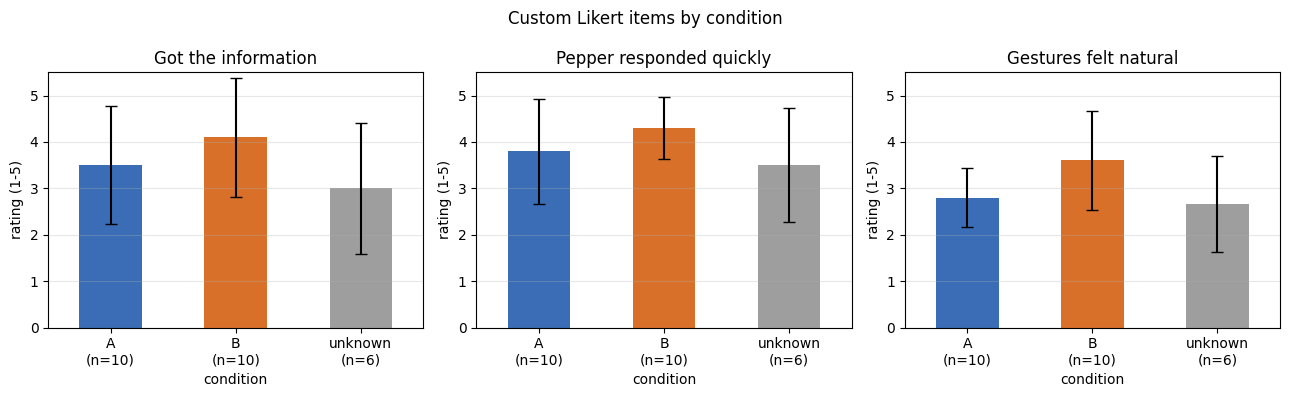

In [46]:
def bar_by_condition(ax, series_per_cond, title, ylabel="rating (1-5)"):
    means = series_per_cond.agg(["mean", "std"]).reindex(COND_ORDER)
    counts = series_per_cond.size().reindex(COND_ORDER).fillna(0).astype(int)
    means["mean"].plot.bar(
        yerr=means["std"], ax=ax, capsize=4,
        color=[COLORS[c] for c in means.index], legend=False,
    )
    ax.set_title(title)
    ax.set_ylim(0, 5.5)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels([f"{c}\n(n={counts[c]})" for c in means.index], rotation=0)
    ax.grid(axis="y", alpha=0.3)

likert_titles = {
    "task_success":        "Got the information",
    "response_speed":      "Pepper responded quickly",
    "gesture_naturalness": "Gestures felt natural",
}

# Print pooled + per-condition means
print(f"=== Per-condition means (mean +/- SD, on 1-5 scale) ===\n")
summary = []
for col, label in likert_titles.items():
    row = {"item": label, "pooled": f"{df[col].mean():.2f} +/- {df[col].std():.2f}"}
    for cond in COND_ORDER:
        sub = df[df["condition"] == cond][col].dropna()
        row[cond] = f"{sub.mean():.2f} +/- {sub.std():.2f}  (n={len(sub)})" if len(sub) else "-"
    summary.append(row)
display(pd.DataFrame(summary))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (col, title) in zip(axes, likert_titles.items()):
    bar_by_condition(ax, df.groupby("condition")[col], title)
plt.suptitle("Custom Likert items by condition")
plt.tight_layout()
plt.show()

## Section 4 — Topic and problems

Multi-select items (visitors could pick several). Split on comma, count each unique value. Use these for §4.4.4 qualitative.

=== What did you talk with Pepper about? (counts across 26 respondents) ===


,count
Navigate to some room,15
Subject schedule,8
Mensa menu,7
General conversation,7
Contact information,3
Toilets,1
Chinese food with Chinese language,1
Navigate to dejvice,1



=== Was there any problem during the interaction? (counts across 26 respondents) ===


,count
No problem,7
The transcription of what I said was incorrect,7
The provided information was false,4
Pepper was slow to respond,4
It was hard to understand what was Pepper saying,2
"Did not understand ""ARI lecture""",1
Bylo to takove chvili zmatene,1
ale asi jsem blbe artikulovala ale na druhy pokus to bylo lepsi,1
It was hard to see the transcription on the tablet,1
She was picking up too much background chatter,1


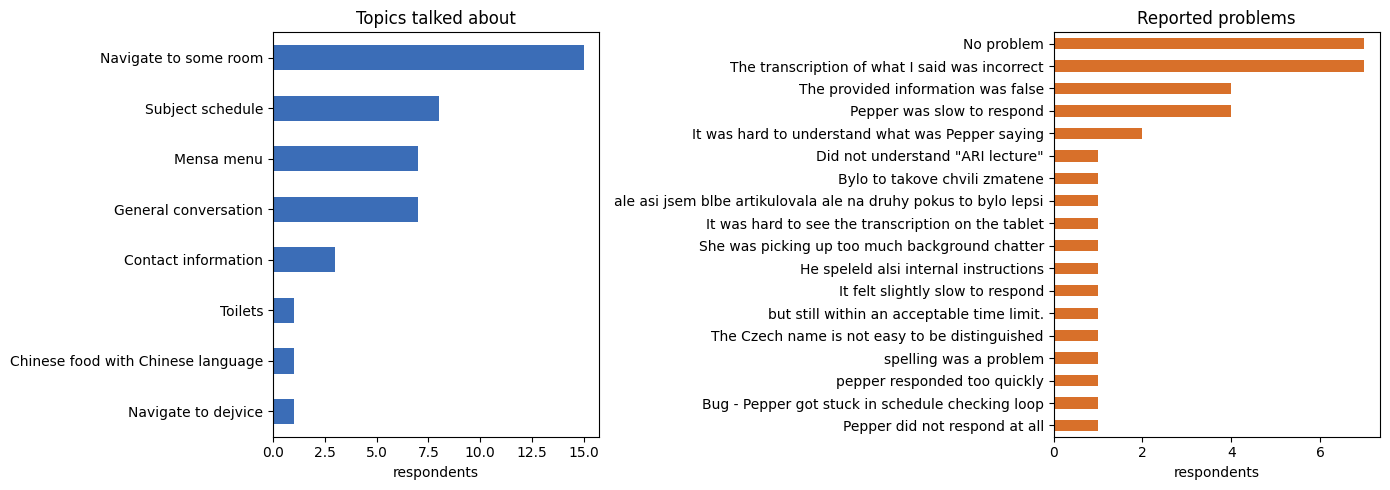

In [47]:
def split_multi(series):
    out = []
    for v in series.dropna():
        for x in [s.strip() for s in str(v).split(",")]:
            if x:
                out.append(x)
    return pd.Series(out)

# Topic
topic_counts = split_multi(df["topic"]).value_counts()
print("=== What did you talk with Pepper about? (counts across 26 respondents) ===")
display(topic_counts.to_frame("count"))

# Problems
problem_counts = split_multi(df["problem"]).value_counts()
print("\n=== Was there any problem during the interaction? (counts across 26 respondents) ===")
display(problem_counts.to_frame("count"))

# Bar plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
topic_counts.plot.barh(ax=axes[0], color="#3b6db7").invert_yaxis()
axes[0].set_title("Topics talked about")
axes[0].set_xlabel("respondents")
problem_counts.plot.barh(ax=axes[1], color="#d8702a").invert_yaxis()
axes[1].set_title("Reported problems")
axes[1].set_xlabel("respondents")
plt.tight_layout()
plt.show()

## Section 5 — Who would you prefer at reception E?

Single-select preference item: human / Pepper / no-one / other (free text).

=== Preference (n=26) ===
  Pepper                          19  (73%)
  Human                            4  (15%)
  Dotyková obrazkovka s plány pater a seznamem osob s tel. čísly   1  (4%)
  both                             1  (4%)
  No one                           1  (4%)


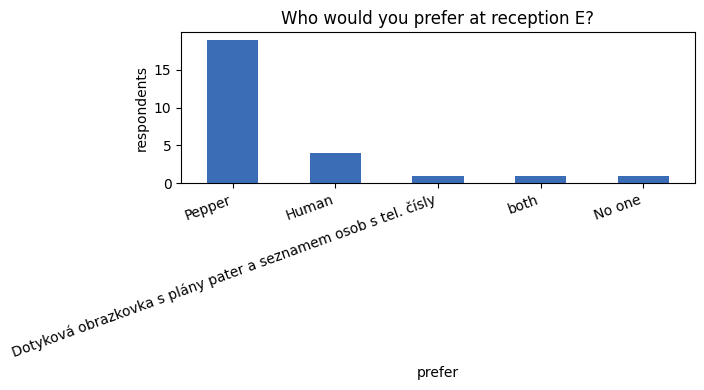

In [48]:
pref_counts = df["prefer"].value_counts(dropna=False)
print(f"=== Preference (n={len(df)}) ===")
for k, v in pref_counts.items():
    pct = 100 * v / len(df)
    print(f"  {str(k):30s} {v:3d}  ({pct:.0f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
pref_counts.plot.bar(ax=ax, color="#3b6db7")
ax.set_title("Who would you prefer at reception E?")
ax.set_ylabel("respondents")
ax.set_xticklabels(pref_counts.index, rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Section 6 — Open-ended responses

Verbatim free-text answers to:

- **Q10**: "What would you like Pepper to be able to help you with?"
- **Q33**: "Anything else you'd like to share?"

Each response is shown with the respondent's `(condition, gender, age, robot_familiarity)` so patterns can be spotted by hand.

In [49]:
def print_free_text(col, title):
    print(f"=== {title} ===\n")
    nonempty = df[df[col].notna() & (df[col].str.strip() != "")]
    if len(nonempty) == 0:
        print("  (no responses)\n")
        return
    for _, r in nonempty.iterrows():
        header = f"[{r['condition']}] {r['gender']}, age {r['age']}, robot-fam {r['robot_familiarity']}"
        print(f"  {header}")
        print(f"    > {r[col]}\n")

print_free_text("help_wishes", "Q10 - What would you like Pepper to be able to help you with?")
print_free_text("comments",    "Q33 - Anything else you'd like to share?")

=== Q10 - What would you like Pepper to be able to help you with? ===

  [B] Female, age 49, robot-fam 1
    > Navigovat

  [unknown] Female, age 25, robot-fam 2
    > Would be cool if it she could call the professor/someone I need to meet to say that I am here.

  [B] Male, age 23, robot-fam 2
    > Events that are/will be happening on the Faculty

  [B] Male, age 22, robot-fam 5
    > Inform about irregular closures and room changes during events

  [B] Male, age 26, robot-fam 2
    > Show menu, not spell int. Automatic cooldown when user dont finish conversation.

  [B] Male, age 29, robot-fam 5
    > Tram schedules to/from Dejvice. Some way to figure out who to talk to if I have a specific problem. Information about different labs in KN.

  [A] Male, age 28, robot-fam 3
    > answer some questions about map

  [A] Male, age 22, robot-fam 4
    > If iam making it to metro or tram.

  [unknown] Male, age 31, robot-fam 5
    > Classroom, professor's office

  [unknown] Male, age 38, r

## Section 7 — Godspeed subscales

Four subscales of the standard Godspeed questionnaire~\cite{bartneck2009godspeed}, each a mean of its bipolar adjective items (1-5):

- **Anthropomorphism** (5 items): fake-natural, machinelike-humanlike, unconscious-conscious, artificial-lifelike, moving rigidly-elegantly.
- **Animacy** (6 items: includes the "artificial-lifelike" item shared with Anthropomorphism in the standard instrument).
- **Likeability** (5 items): dislike-like, unfriendly-friendly, unkind-kind, unpleasant-pleasant, awful-nice.
- **Perceived Intelligence** (5 items): incompetent-competent, ignorant-knowledgeable, irresponsible-responsible, unintelligent-intelligent, foolish-sensible.

The 5th Godspeed subscale (Perceived Safety) was not included in the questionnaire (see thesis §4.3).

In [50]:
SUBSCALES = {
    "Anthropomorphism":       [c for c in df.columns if c.startswith("anthro_")],
    "Animacy":                [c for c in df.columns if c.startswith("animacy_")],
    "Likeability":            [c for c in df.columns if c.startswith("like_")],
    "Perceived Intelligence": [c for c in df.columns if c.startswith("intel_")],
}

# Per-respondent subscale scores
scores = pd.DataFrame({name: df[cols].mean(axis=1) for name, cols in SUBSCALES.items()})
scores["condition"] = df["condition"]

# Cronbach's alpha
def cronbach_alpha(items):
    items = items.dropna()
    k = items.shape[1]
    if k < 2 or len(items) < 2: return float("nan")
    item_var = items.var(axis=0, ddof=1).sum()
    total_var = items.sum(axis=1).var(ddof=1)
    if total_var == 0: return float("nan")
    return (k / (k - 1)) * (1 - item_var / total_var)

print(f"=== Subscale means (mean +/- SD, on 1-5 scale) ===\n")
rows = []
for name, cols in SUBSCALES.items():
    alpha = cronbach_alpha(df[cols])
    row = {"subscale": name, "alpha": f"{alpha:.2f}",
           "pooled": f"{scores[name].mean():.2f} +/- {scores[name].std():.2f}"}
    for cond in COND_ORDER:
        sub = scores[scores["condition"] == cond][name].dropna()
        row[cond] = f"{sub.mean():.2f} +/- {sub.std():.2f}  (n={len(sub)})" if len(sub) else "-"
    rows.append(row)
display(pd.DataFrame(rows))

=== Subscale means (mean +/- SD, on 1-5 scale) ===



,subscale,alpha,pooled,A,B,unknown
0,Anthropomorphism,0.72,2.72 +/- 0.70,2.58 +/- 0.94 (n=10),2.84 +/- 0.62 (n=10),2.73 +/- 0.30 (n=6)
1,Animacy,0.75,3.19 +/- 0.66,3.18 +/- 0.78 (n=10),3.30 +/- 0.59 (n=10),3.00 +/- 0.61 (n=6)
2,Likeability,0.81,4.33 +/- 0.51,4.20 +/- 0.47 (n=10),4.46 +/- 0.60 (n=10),4.33 +/- 0.41 (n=6)
3,Perceived Intelligence,0.80,3.45 +/- 0.67,3.38 +/- 0.91 (n=10),3.58 +/- 0.54 (n=10),3.33 +/- 0.47 (n=6)


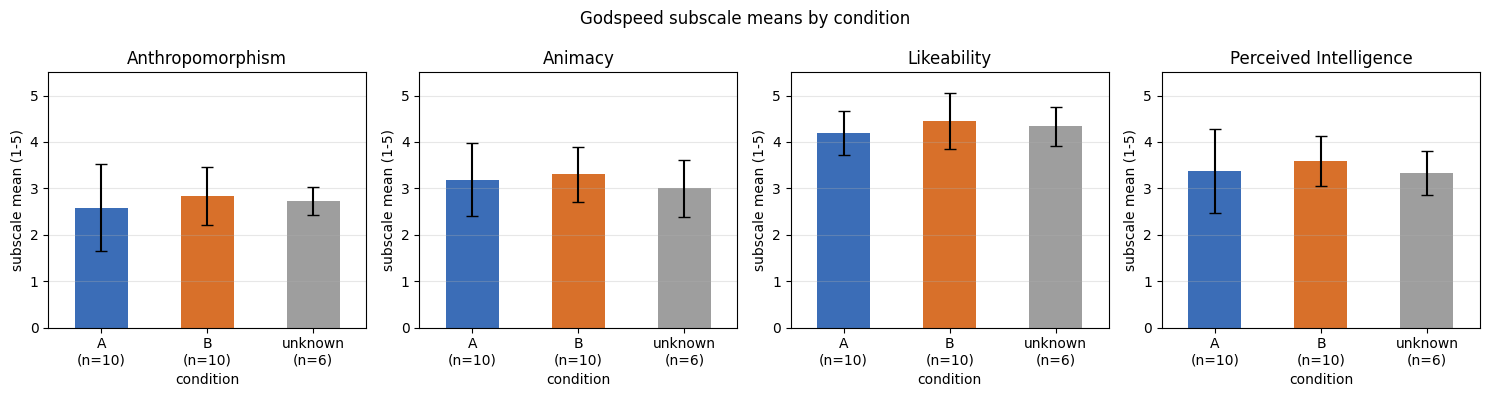

In [51]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, name in zip(axes, SUBSCALES.keys()):
    by_cond = scores.groupby("condition")[name].agg(["mean", "std"]).reindex(COND_ORDER)
    counts  = scores.groupby("condition")[name].count().reindex(COND_ORDER).fillna(0).astype(int)
    by_cond["mean"].plot.bar(
        yerr=by_cond["std"], ax=ax, capsize=4,
        color=[COLORS[c] for c in by_cond.index], legend=False,
    )
    ax.set_title(name)
    ax.set_ylim(0, 5.5)
    ax.set_ylabel("subscale mean (1-5)")
    ax.set_xticklabels([f"{c}\n(n={counts[c]})" for c in by_cond.index], rotation=0)
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("Godspeed subscale means by condition")
plt.tight_layout()
plt.show()

## Section 8 — Summary

Headline numbers from the questionnaire, for §4.4.2 of the thesis.

In [52]:
print(f"=== SUBJECTIVE HEADLINE (n={len(df)} respondents; A={(df['condition']=='A').sum()} / B={(df['condition']=='B').sum()} / unknown={(df['condition']=='unknown').sum()}) ===\n")

print("Custom Likert items (mean on 1-5 scale):")
for col, label in likert_titles.items():
    print(f"  {label:30s} pooled = {df[col].mean():.2f}    "
          f"A = {df[df['condition']=='A'][col].mean():.2f}    "
          f"B = {df[df['condition']=='B'][col].mean():.2f}    "
          f"unknown = {df[df['condition']=='unknown'][col].mean():.2f}")

print()
print("Godspeed subscales (mean on 1-5 scale):")
for name in SUBSCALES:
    pooled = scores[name].mean()
    by_cond = scores.groupby("condition")[name].mean()
    print(f"  {name:25s} pooled = {pooled:.2f}    "
          f"A = {by_cond.get('A', float('nan')):.2f}    "
          f"B = {by_cond.get('B', float('nan')):.2f}    "
          f"unknown = {by_cond.get('unknown', float('nan')):.2f}")

=== SUBJECTIVE HEADLINE (n=26 respondents; A=10 / B=10 / unknown=6) ===

Custom Likert items (mean on 1-5 scale):
  Got the information            pooled = 3.62    A = 3.50    B = 4.10    unknown = 3.00
  Pepper responded quickly       pooled = 3.92    A = 3.80    B = 4.30    unknown = 3.50
  Gestures felt natural          pooled = 3.08    A = 2.80    B = 3.60    unknown = 2.67

Godspeed subscales (mean on 1-5 scale):
  Anthropomorphism          pooled = 2.72    A = 2.58    B = 2.84    unknown = 2.73
  Animacy                   pooled = 3.19    A = 3.18    B = 3.30    unknown = 3.00
  Likeability               pooled = 4.33    A = 4.20    B = 4.46    unknown = 4.33
  Perceived Intelligence    pooled = 3.45    A = 3.38    B = 3.58    unknown = 3.33


## Section 9 — Point overlay plots (supervisor feedback)

Same bar + SD comparison as Sections 3 and 7, but with individual respondent ratings overlaid as a strip plot. Each dot is one respondent, so the reader sees the actual spread behind the SD whisker instead of only the aggregate.

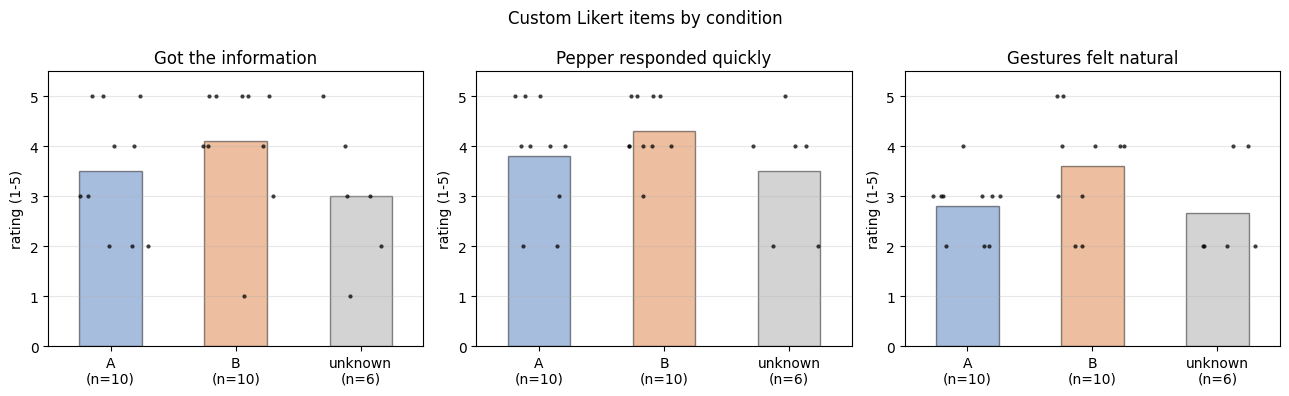

In [66]:
import seaborn as sns

def bar_with_points(ax, data, value_col, title, ylabel="rating (1-5)", ylim=(0, 5.5)):
    by_cond = data.groupby("condition")[value_col].mean().reindex(COND_ORDER)
    counts  = data.groupby("condition")[value_col].count().reindex(COND_ORDER).fillna(0).astype(int)
    by_cond.plot.bar(
        ax=ax,
        color=[COLORS[c] for c in by_cond.index], legend=False,
        alpha=0.45, edgecolor="black",
    )
    sns.stripplot(
        data=data, x="condition", y=value_col, order=COND_ORDER,
        ax=ax, color="black", size=3, alpha=0.75, jitter=0.30,
    )
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()
    ax.set_title(title)
    ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_xticklabels([f"{c}\n(n={counts[c]})" for c in COND_ORDER], rotation=0)
    ax.grid(axis="y", alpha=0.3)

# Custom Likert items with point overlay
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (col, title) in zip(axes, likert_titles.items()):
    bar_with_points(ax, df[["condition", col]].dropna(), col, title)
plt.suptitle("Custom Likert items by condition")
plt.tight_layout()
fig.savefig(PROJECT_ROOT / "likert_points.png", dpi=200, bbox_inches="tight")
plt.show()

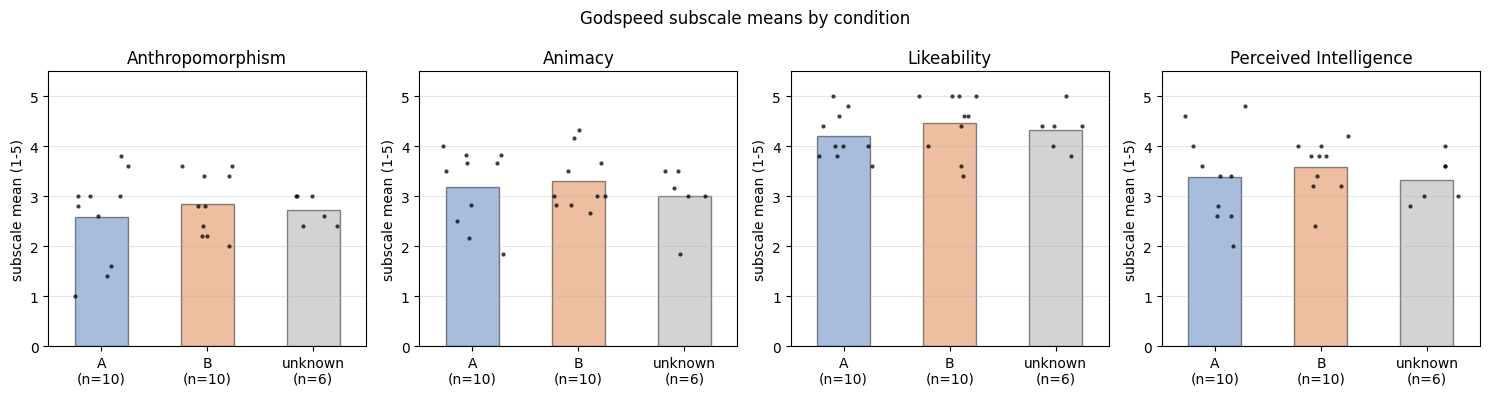

In [54]:
# Godspeed subscales with point overlay
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, name in zip(axes, SUBSCALES.keys()):
    bar_with_points(ax, scores[["condition", name]].dropna(), name, name, ylabel="subscale mean (1-5)")
plt.suptitle("Godspeed subscale means by condition")
plt.tight_layout()
fig.savefig(PROJECT_ROOT / "godspeed_points.png", dpi=200, bbox_inches="tight")
plt.show()